# SPRINT 11
## Nivel 1
### Ejercicio 1
1. Connecta Python amb MySQL Workbench i carrega les dades de la teva base de dades del Sprint 4 per utilitzar-les en tots els exercicis.
2. Per a cada ítem, crea una visualització adequada segons les variables especificades. Interpreta els resultats segons les teves dades.

In [2]:
# 1. Conexión con la Base de Datos en MySQL
import mysql.connector
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from mysql.connector import Error

In [3]:
# 1. Conexión a la base de datos 'ventas_toys'
try:
    connection = mysql.connector.connect(
        host="localhost",
        port=3306,
        user="root",
        password="Sverige2011*",
        database="ventas_toys"
    )

    # 2. Verificamos que se haya conectado correctamente
    if connection.is_connected():
        df_Info = connection.get_server_info()
        print("Conectado con éxito al servidor MySQL versión:", df_Info)
        
        # Abrimos el canal para hacer la prueba con cursor
        cursor = connection.cursor()
        cursor.execute("SELECT database();")
        record = cursor.fetchone()
        print("Confirmado. Base de datos activa:", record[0])

# 3. Si algo falla en los pasos anteriores, campturamos el error de MySQL
except Error as e:
    print("Error al intentar conectar a MySQL:", e)

# 4. Pase lo que pase limpiamos memoria y cerramos conexiones colgadas
finally:
    # Si la variable 'connection' sigueabierta la cerramos de forma segura
    if 'connection' in locals() and connection.is_connected():
        cursor.close()
        connection.close()
        print("Conexión cerrada de forma segura. Servidor liberado.")

Conectado con éxito al servidor MySQL versión: 8.0.45
Confirmado. Base de datos activa: ventas_toys
Conexión cerrada de forma segura. Servidor liberado.


C:\Users\ivan_\AppData\Local\Temp\ipykernel_8684\3659693294.py:13: DeprecationWarning: Call to deprecated function get_server_info. Reason: 
    The property counterpart 'server_info' should be used instead.

  df_Info = connection.get_server_info()


In [4]:
# Bloque para importar las tablas de la Base de DAtos 'ventas_toys'
# Configuración estética global
sns.set_theme(style="whitegrid")

# JOIN con las tablas clave
query = """
SELECT
    t.id AS transaction_id,
    t.timestamp,
    t.amount,
    t.declined,
    tp.product_id,
    p.product_name,
    p.price,
    u.country AS user_country,
    u.region AS user_region,
    c.company_name
FROM transactions t
JOIN transaction_products tp ON t.id = tp.transaction_id
JOIN products p ON tp.product_id = p.id
JOIN users u ON t.user_id = u.id
JOIN companies c ON t.company_id = c.company_id;
"""

try:
    connection = mysql.connector.connect(
        host="localhost",
        port=3306,
        database="ventas_toys",
        user="root",
        password="Sverige2011*"
    )
    df_ventas_toys = pd.read_sql(query, connection)
    print("Dataframe cargado con éxito en la variable 'df_ventas_toys'.")

except mysql.connector.Error as e:
    print("Error al extraer los datos desde MySQL:", e)

finally:
    if 'connection' in locals() and connection.is_connected():
        connection.close()
        print("Conexión con Mysql cerrada de forma segura")

# Preparación de las variables para el ejercicio
if 'df_ventas_toys' in locals():
    # Convervitmos la fecha y extraemos la hora (variable numérica)
    df_ventas_toys['hour'] = pd.to_datetime(df_ventas_toys['timestamp']).dt.hour

    print("VARIABLES LISTAS")
    print(f"Numéricas: 'amount' (importe), 'price' (precio unitario), 'hour' (hora)")
    print(f"Categóricas: 'product_name', 'user_country', 'user_region', 'company_name', 'declined'")
    print(f"Dimensiones del DataFRame local: {df_ventas_toys.shape}")

C:\Users\ivan_\AppData\Local\Temp\ipykernel_8684\1511777105.py:33: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_ventas_toys = pd.read_sql(query, connection)


Dataframe cargado con éxito en la variable 'df_ventas_toys'.
Conexión con Mysql cerrada de forma segura
VARIABLES LISTAS
Numéricas: 'amount' (importe), 'price' (precio unitario), 'hour' (hora)
Categóricas: 'product_name', 'user_country', 'user_region', 'company_name', 'declined'
Dimensiones del DataFRame local: (253391, 11)


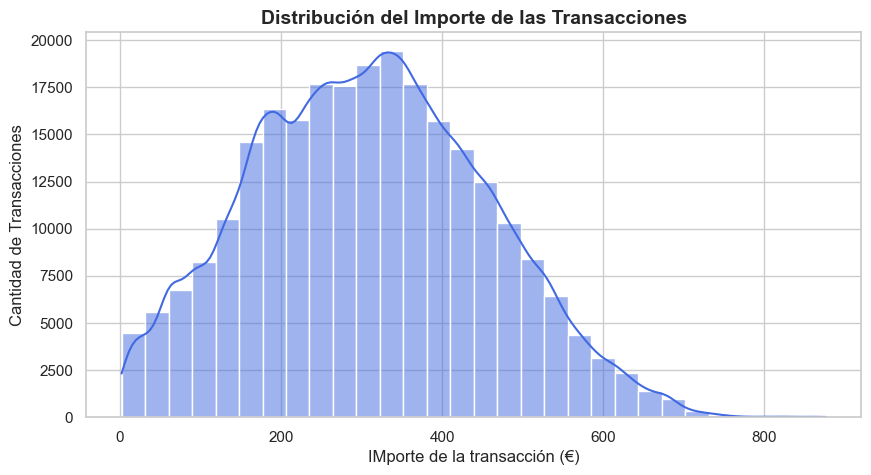

In [5]:
# Item 1: Una variable numérica
plt.figure(figsize=(10,5))

sns.histplot(data=df_ventas_toys, x='amount', bins=30, color='royalblue', kde=True)

plt.title('Distribución del Importe de las Transacciones', fontsize=14, fontweight='bold')
plt.xlabel('IMporte de la transacción (€)', fontsize=12)
plt.ylabel('Cantidad de Transacciones', fontsize=12)

plt.show()

### Análisis del resultado - Item 1
- Los datos siguen una distribución unimodal (campana de Gauss), ligeramente sesgada a ka derecha.
- No es una tienda de micro-compras ni de compras de masivas de lujo. El grueso de las transacciones se concentra en un rango medio.
- El pico máximo (moda) de ventas se sitúa en torno a los 330-350€, alcanzando casi los 19.500 transacciones en ese interval.
- La gran mayoría de los clientes gasta entre 150€ y 550€ por trasacción aproximádamente.
- Las compras inferiores a 50€ son escasas y a partir de los 600€ el volumen cae drásticamente.

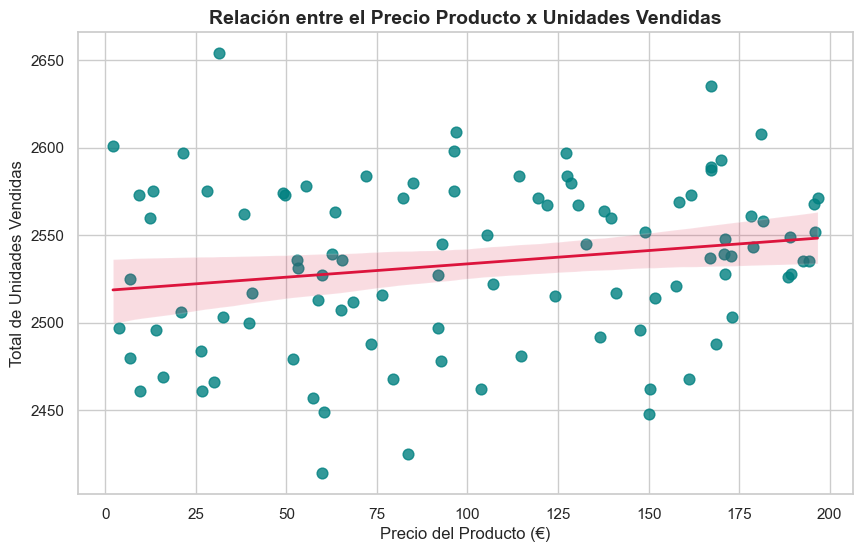

In [6]:
#Item 2 (A): Dos variables numéricas (precio x unidades vendidas)
# Agrupamos por producto para contar cuántas unidades se vendieron de cada uno
df_unidades_producto = df_ventas_toys.groupby('product_id').agg(
    precio=('price', 'first'),
    unidades_vendidas=('transaction_id', 'count')
).reset_index()

# Dibujamos el gráfico de dispersión con línea de tendencia (regplot)
plt.figure(figsize=(10, 6))
sns.regplot(
    data=df_unidades_producto,
    x='precio',
    y='unidades_vendidas',
    scatter_kws={'alpha':0.8, 'color': 'teal', 's': 60},
    line_kws={'color': 'crimson', 'linewidth': 2}
)

plt.title('Relación entre el Precio Producto x Unidades Vendidas', fontsize=14, fontweight='bold')
plt.xlabel('Precio del Producto (€)', fontsize=12)
plt.ylabel('Total de Unidades Vendidas', fontsize=12)

plt.show()

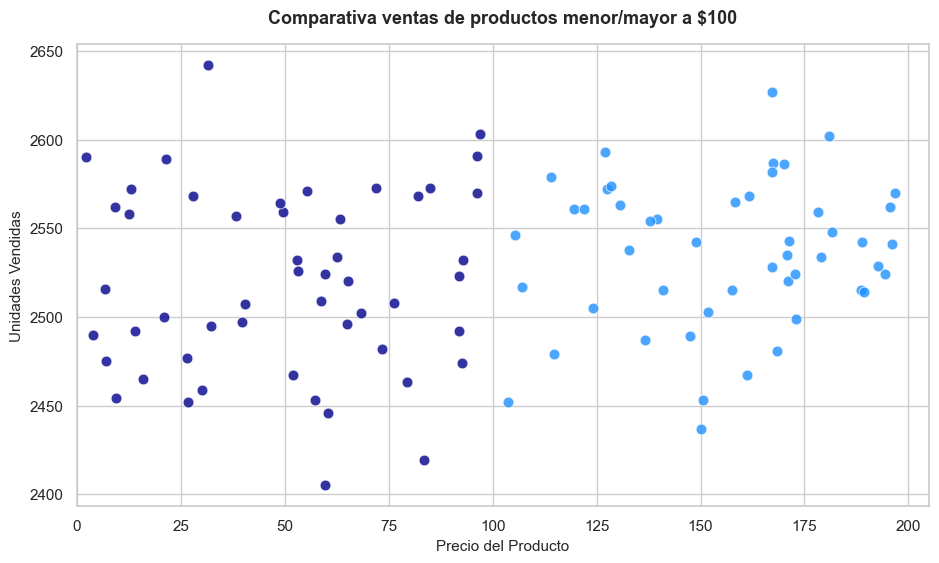

In [7]:
# Item 2 (B): Dos variables numéricas (Precio Producto x Unidades Vendidas) (NO rechazadas)
# 1. Aplicamos el filtro [declined] = FALSE()
df_no_rechazadas = df_ventas_toys[df_ventas_toys['declined'] == 0]

# 2. Agrupamos por product_id
df_unidades_x_producto = df_no_rechazadas.groupby('product_id').agg(
    precio_medio=('price', 'mean'),     #similar al sprint de Power BI
    unidades_vendidas=('transaction_id', 'count')
).reset_index()

# 3. Dibujamos el scatterplot
plt.figure(figsize=(11, 6))

#pintamos con dos colores simulando la lógica aplicada en el Power BI (menor/mayor de 100€)
sns.scatterplot(
    data=df_unidades_x_producto[df_unidades_x_producto['precio_medio'] <= 100],
    x='precio_medio', y='unidades_vendidas', color='darkblue', s=60, alpha=0.8
)
sns.scatterplot(
    data=df_unidades_x_producto[df_unidades_x_producto['precio_medio'] > 100],
    x='precio_medio', y='unidades_vendidas', color='dodgerblue', s=60, alpha=0.8
)

#títulos
plt.title('Comparativa ventas de productos menor/mayor a $100', fontsize=13, fontweight='bold', pad=15)
plt.xlabel('Precio del Producto', fontsize=11)
plt.ylabel('Unidades Vendidas', fontsize=11)
plt.xlim(0, 205)

plt.show()

### Análisis de resultado - Item 2
- La distribución horizontal de los puntos confirma que el volumen de unidades vendidas es constante (aroximadamente 2.500 unidades por producto) sin importar su coste. El precio no actúa como una barrera de compra para los clientes.

C:\Users\ivan_\AppData\Local\Temp\ipykernel_8684\3957910062.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


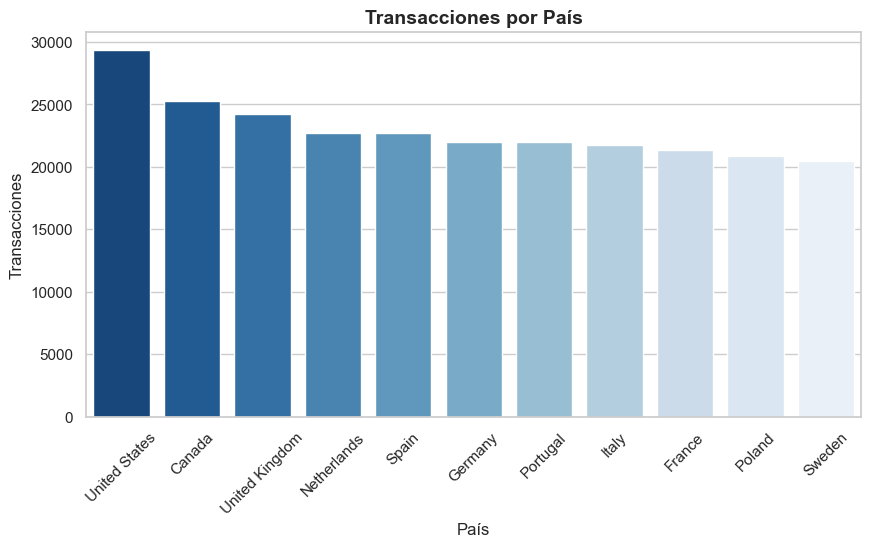

In [8]:
# Item 3: Una variable categórica
# Transacciones por País
plt.figure(figsize=(10, 5))

sns.countplot(
    data=df_no_rechazadas,
    x='user_country',
    palette='Blues_r',
    order=df_no_rechazadas['user_country'].value_counts().index
)

plt.title('Transacciones por País', fontsize=14, fontweight='bold')
plt.xlabel('País', fontsize=12)
plt.ylabel('Transacciones', fontsize=12)

plt.xticks(rotation=45, ha='center')

plt.show()

### Análisis de resultado - Item 3
- El Top 5 con el mayor número de transacciones son:
1. Estados Unidos
2. Canadá
3. Reino Unido
4. Países Bajos
5. España

C:\Users\ivan_\AppData\Local\Temp\ipykernel_8684\182443806.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


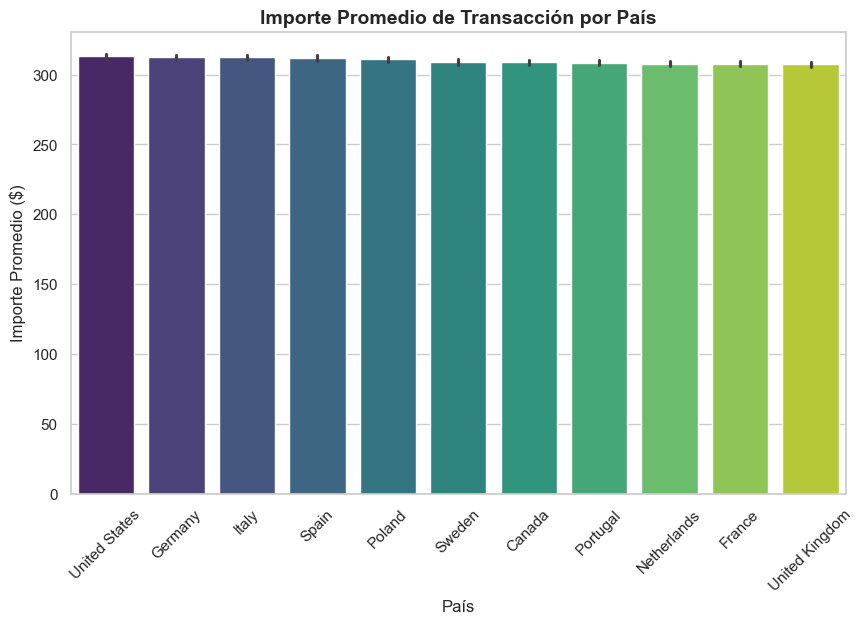

In [10]:
# Item 4: Una variable categórica y una numérica (Importe medio por País)
plt.figure(figsize=(10, 6))

sns.barplot(
    data=df_no_rechazadas,
    x='user_country',
    y='amount',
    palette='viridis',
    order=df_no_rechazadas.groupby('user_country')['amount'].mean().sort_values(ascending=False).index,
)

plt.title('Importe Promedio de Transacción por País', fontsize=14, fontweight='bold')
plt.xlabel('País', fontsize=12)
plt.ylabel('Importe Promedio ($)', fontsize=12)

plt.xticks(rotation=45, ha='center')

plt.show()


### Análisis del resultado - Item 4
- Lo países con el promedio más alto por transacción son: Estados unidos, Alemania, Italia, España, Polonia, Suecia, Canadá, Portugal, Paises Bajos, Francia y Reino Unido. En ese orden.

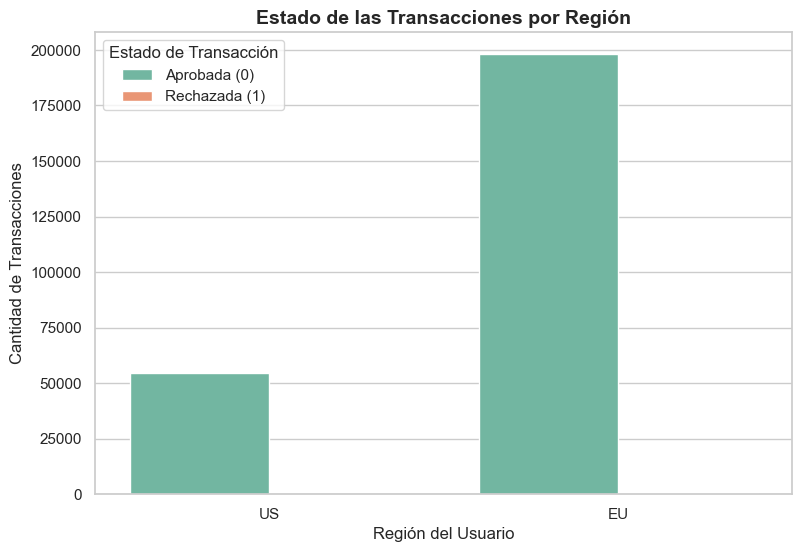

In [11]:
# Item 5: Dos variables categóricas (región vs estado de transacción
plt.figure(figsize=(9, 6))

#usamos el DataFrame completo
sns.countplot(
    data=df_ventas_toys,
    x='user_region',
    hue='declined',
    palette='Set2'
    )

plt.title('Estado de las Transacciones por Región', fontsize=14, fontweight='bold')
plt.xlabel('Región del Usuario', fontsize=12)
plt.ylabel('Cantidad de Transacciones', fontsize=12)

plt.legend(title='Estado de Transacción', labels=['Aprobada (0)', 'Rechazada (1)'])

plt.show()

### Comprobaciones

In [10]:
print(df_ventas_toys['declined'].value_counts())

declined
0    252693
1       698
Name: count, dtype: int64


In [11]:
pd.crosstab(df_ventas_toys['user_region'], df_ventas_toys['declined'], margins=True)

declined,0,1,All
user_region,,,
EU,198052,392,198444
US,54641,306,54947
All,252693,698,253391


### Análisis del resultado - Item 5
- El mercado de Estados Unidos presenta una vulnerabilidad financiera significativamente mayor que el Europeo. La tasa de transacciones rechazadas en US alcanza el 0,55% (306 rechazadas), frente a un 0,19% en EU (392 rechazadas).
- Aunque en número absolutos Europa registre más transacciones rechazadas, esto se debe únicamente a que la Unión Europea concentra el 78% del volumen total de compras de la tienda (1988.444 transacciones)
- Proporcionalmente, una tarjeta de un cliente americano tiene casi el triple de probabilidad de ser rechazada que la de un cliente europeo, lo que sugiere la nacesidad de revisar las pasarelas de pago o las alertas de fraude en la región de US.

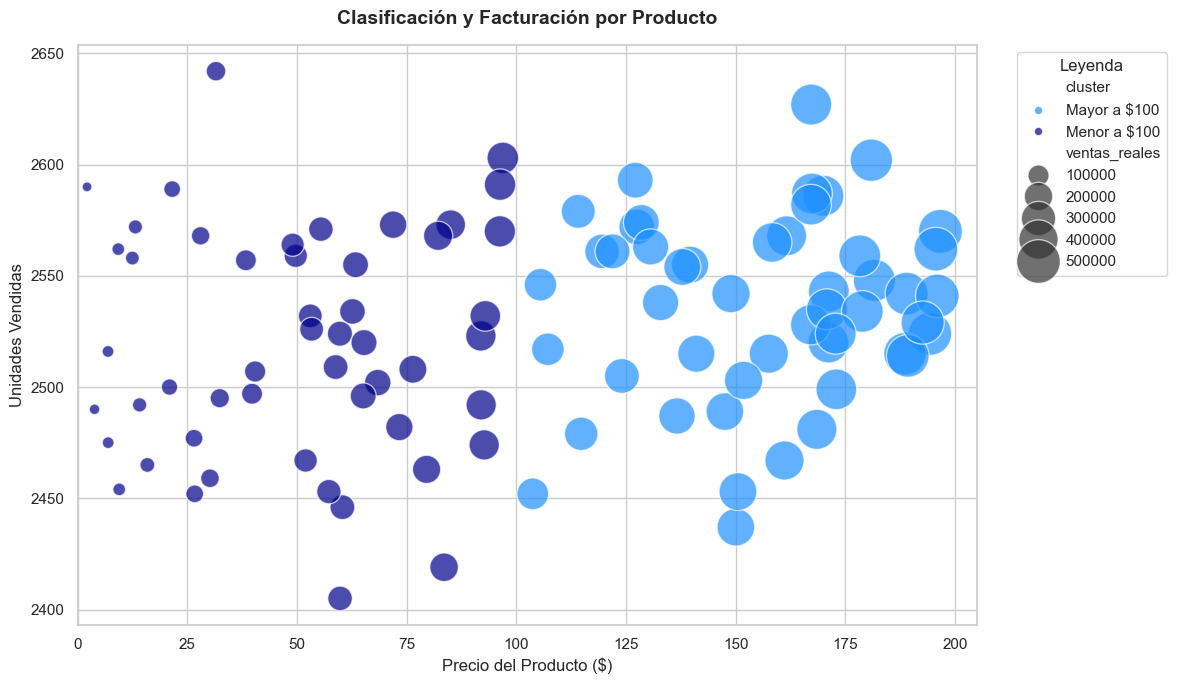

In [12]:
# Item 6: Tres variables combinadas
# X: Precio / Y: Unidades / Tamaño: Ventas reales / Leyenda: Clústeres
plt.figure(figsize=(12, 7))

# agrupamos por ID del producto
df_item6 = df_no_rechazadas.groupby('product_id').agg(
    precio=('price', 'first'),
    unidades_vendidas=('transaction_id', 'count'),
    ventas_reales=('price', 'sum')
).reset_index()

# creamos la leyenda de menores/mayores de 100$
df_item6['cluster'] = np.where(df_item6['precio'] <= 100, 'Menor a $100', 'Mayor a $100')

# dibujamos el gráfico combinado 'hue' (colores) y 'size' (tamaño)
sns.scatterplot(
    data=df_item6,
    x='precio',
    y='unidades_vendidas',
    hue='cluster',
    size='ventas_reales',
    sizes=(50, 1000),
    palette={'Menor a $100': 'darkblue', 'Mayor a $100': 'dodgerblue'},
    alpha=0.7
)

plt.title('Clasificación y Facturación por Producto', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Precio del Producto ($)', fontsize=12)
plt.ylabel('Unidades Vendidas', fontsize=12)
plt.xlim(0, 205)

plt.legend(title='Leyenda', loc='upper right', bbox_to_anchor=(1.22, 1))
plt.tight_layout()

plt.show()

### Análisis del resultado - Item 6
- La distribución horizontal de los puntos confirma que el volumen de unidades vendidas es constante (aroximadamente 2.500 unidades por producto) sin importar su coste. El precio no actúa como una barrera de compra para los clientes.
- El clúster de productos de gama alta (mayor de $100) está representado por burbujas notablemente más grandes. Esto demuestra visualmente que, a igualdad de unidades vendidas, estos artículos inyectan un volumen de ingresos muy superior al negocio.
- Aunque un jueguete de $200 registre la misma cantidad de transacciones que uno de $20, el producto caro multiplica por 10 el retorno económico directo, consolidándose como el verdadero motor financiero de la tienda.

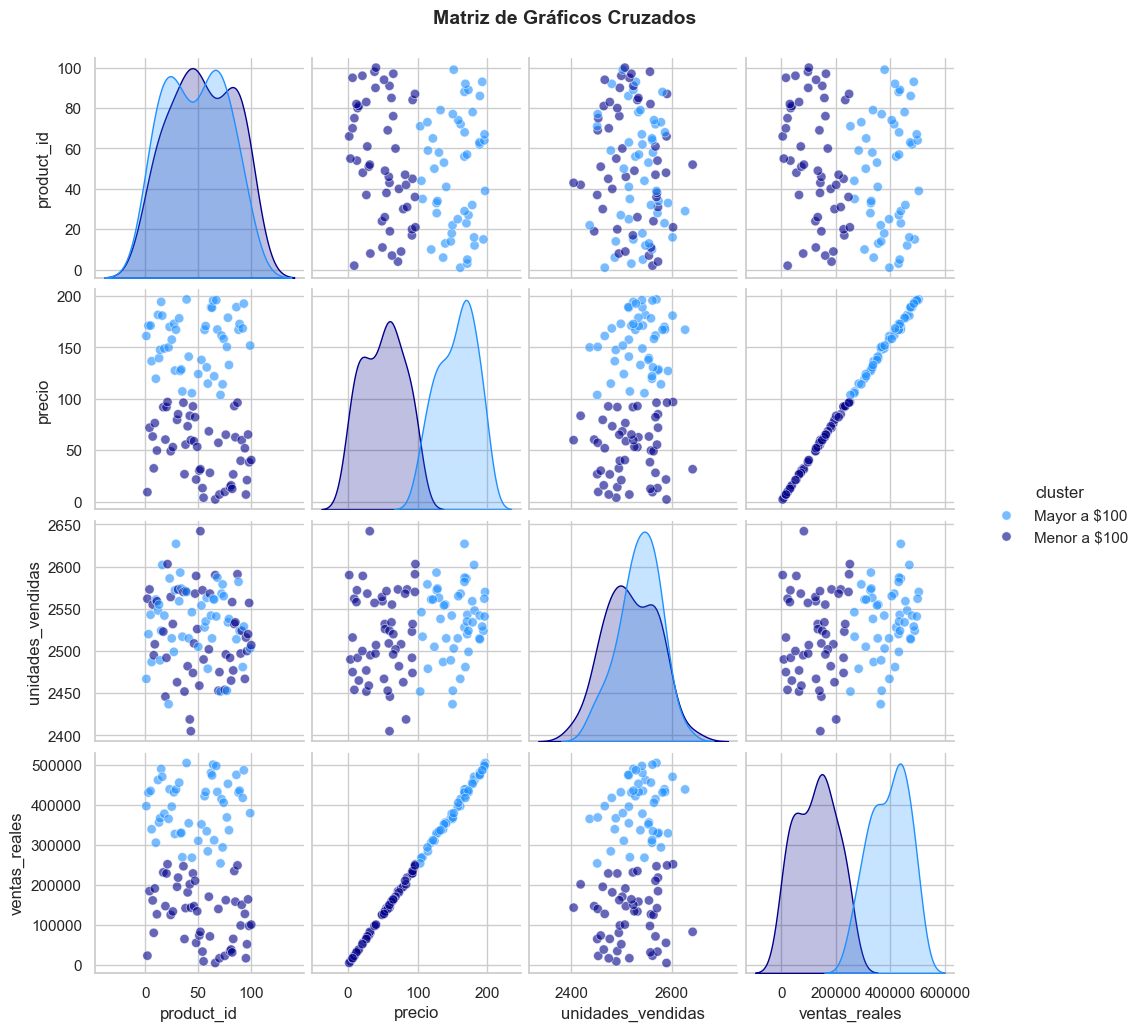

In [13]:
# Item 7: Pairplot

g = sns.pairplot(
    data=df_item6,
    hue='cluster',
    palette={'Menor a $100': 'darkblue', 'Mayor a $100': 'dodgerblue'},
    plot_kws={'alpha': 0.6, 's': 45}
)

g.figure.suptitle('Matriz de Gráficos Cruzados', y=1.03, fontsize=14, fontweight='bold')

plt.show()

### Análisis del resultado - Item 7
- Comportamiento uniforme de la demanda. El cruce entre precio y unidades_vendidas forma un bloque rectangular regular. ESto demuestra que la cantidad de unidades vendidas es idéntica (aprox. 2500 unidades por producto) e independiente del coste del producto.
- Correlación lineal perfecta en la facturación. Al mantenerse las unidades vendidas constantes, la variable ventas_reales presenta una correlación positiva respecto al precio. Cada euro de incremento en el coste de producto se traduce en un escalado directo de los ingresos totales.
- Simetría en la distribución de ctálogo. Las montañas de densidad de los clusteres (menor/mayor de 100) se solapan casi por completo en las variables de control. Esto indica que los productos caros y baratos se distribuyen con las mismas frecuencias de ventas.
- Concentración de identificadores centrales. La diagonal de product_id revela una distribución multimodal concentrada en el centro. Los productos con identificadores intermedios (IDs del 40 al 60) acumulan el mayor volumen de transacciones de la tienda, mientras que los ids extremos muestran una actividad residual.